---
# Synthetic data generation and Cryo-CT reconstruction - 3D X-ray tomography
##         _Basic and advanced methods_
---

In [1]:
#%matplotlib ipympl
from tqdm.notebook import trange, tqdm
import jupyter_compare_view
import numpy as np
from jupyter_compare_view import compare
import jupyter
import matplotlib.pyplot as plt
import scipy as sp
import warnings as warn
import pyxu.experimental.xray as pxr
import sys
import mrcfile
import tqdm
import pyxu.util as pxu
import pyxu.opt.stop as pxst
import cupy as cp
import pyxu.abc as pxa
from pyxu.opt.solver import pgd, PGD, CV
from pyxu.abc import ProxFunc
from pyxu.operator import Convolve
import matplotlib
from contrasttransferfunction import ContrastTransferFunction
import torch
from pyxu.operator.interop import from_torch
from pyxu.operator import Gradient, SquaredL2Norm, L1Norm, L21Norm, PositiveL1Norm, PositiveOrthant
from pyxu.opt.solver import PD3O
from pyxu.operator import blocks
import scipy.ndimage.interpolation as interp
import time
import torch
import random
import numpy as np
import torch.nn as nn
from training.utils import utils
from training.utils.utilities import batch_PSNR
from matplotlib import pyplot as plt
import pyxu.runtime as pxrt
from load_data import get_proj

Jupyter compare_view v0.2.4


### Using GPU. Device 0 with server.
> $\texttt{mempool}$ is the default memory variable in cupy

In [2]:
cp.cuda.Device(0).use()
mempool = cp.get_default_memory_pool()
mempool.free_all_blocks()

### Loading ground truth

In [3]:
# ========= IMOD reconstruction from Bern =========
gt = 'synthetic_data/model_0/grandmodel.mrc'
with mrcfile.open(gt, 'r') as mrc:
    gt = mrc.data # (Nangles, 1024 1024)
v_shape_bern = gt.shape

### Data and volume definition
>$\texttt{ratio}$ is the upsampling factor of data, to get denser rays pass by the volume while projecting/backprojecting (avoid artifacts).

In [4]:
warn.filterwarnings("ignore")
plt.rcParams["image.cmap"] = "gray"

# Capture command-line arguments
mrc_filename = 'synthetic_data/model_0/noisefree_projections.mrc'
tlt_filename = 'Position_12.tlt'

# Load the MRC file
with mrcfile.open(mrc_filename, 'r') as mrc:
    tilt_series = mrc.data # (Nangles, 1024 1024)

N_view, N_h, N_w = tilt_series.shape

# FOR SYNTHETIC DATA
N_view = 2048
theta = np.linspace(-180, 180, N_view, endpoint=False)
print(N_view, N_h, N_w)
print('theta:', theta)  

2048 1024 1024
theta: [-180.         -179.82421875 -179.6484375  ...  179.47265625  179.6484375
  179.82421875]


In [5]:
ratio = 1
new_tilt = np.zeros((N_view, ratio*N_h, ratio*N_w))
tilt_series = new_tilt

N_view, N_h, N_w = tilt_series.shape
roi_volume = 100 #270//2 #400 fits with pinc
width_volume = 360 # width=220 found with volume ratio   
roi = roi_volume * ratio
width, N_side, N_depth = width_volume * ratio, N_h, 2*roi    

v_shape = (width_volume, N_h//ratio, 2*roi_volume)

print('Volume shape:', v_shape)
print('Tilt series shape:', tilt_series.shape)

Volume shape: (360, 1024, 200)
Tilt series shape: (2048, 1024, 1024)


In [6]:
N_angle = tilt_series.shape[0]
N_offset = tilt_series.shape[1]
N_side = tilt_series.shape[1]

pitch = 1.

# Let's build the necessary components to instantiate the operator. ========================
angle = np.array(theta)*np.pi/180 
n = np.stack([np.cos(angle), np.sin(angle)], axis=1)

t = n[:, [1, 0]] * np.r_[-1, 1]

t_max = pitch * (N_side-1) / 2 * 1 
t_offset = np.linspace(-t_max, t_max, N_offset, endpoint=True)


In [7]:

n_spec = np.broadcast_to(n.reshape(N_angle, 1, 2), (N_angle, N_offset, 2))  # (N_angle, N_offset, 2)
t_spec = t.reshape(N_angle, 1, 2) * t_offset.reshape(N_offset, 1)  # (N_angle, N_offset, 2)

#last dimension is the z axis depth offset. broadcast to shape (N_angle, N_offset, N_offset)
n_spec = np.broadcast_to(n_spec.reshape(N_angle, N_offset, 1, 2), (N_angle, N_offset, N_depth, 2))
# add new axis of n_spec is the z axis depth angle, which is 0 for all rays : shape is (N_angle, N_offset, N_offset, 3)
n_spec = np.concatenate([n_spec, np.zeros((N_angle, N_offset, N_depth, 1))], axis=-1)

t_spec = np.broadcast_to(t_spec.reshape(N_angle, N_offset, 1, 2), (N_angle, N_offset, N_depth, 2))
t_spec = np.concatenate([t_spec, np.zeros((N_angle, N_offset, N_depth, 1))], axis=-1)
t_max = pitch * (N_depth-1) / 2 * 1  # 10% over ball radius
t_spec[:,:,:,2] = np.linspace(-t_max, t_max, N_depth, endpoint=True).reshape(1,1,N_depth) 

N_side = int(N_side)
v_shape = v_shape[0], int(v_shape[1]), v_shape[2]
t_spec += pitch * np.array([1.*width/2, (1.*N_side)/2, 1*N_depth/2]) # Move anchor point to the center of volume. before 5*Nwidth/2

print('param shape : ', t_spec.shape)
print('vshape : ', v_shape)

param shape :  (2048, 1024, 200, 3)
vshape :  (360, 1024, 200)


In [8]:
t_spec = cp.array(t_spec, dtype=cp.float32)
n_spec = cp.array(n_spec, dtype=cp.float32)

### X-ray transform operator
> $\texttt{op\_para\_u}$ is the X-ray operator with $\texttt{apply}$ and $\texttt{adjoint}$ attributes corresponding to the projection/backprojection.
\begin{equation}
    \mathcal{P}_{\theta}\{f\}(z) = \int_{\mathbb{R}} f(t \theta+{P}_{\theta^{\perp}}^{T}z)\ \mathrm{d} t,
\end{equation}

In [9]:
op_para_u = pxr.XRayTransform.init(
    arg_shape=v_shape, #volume size
    origin= (0, 0, 0),  # bottom-left corner of volume located at (0, 0) (N_side/2 - width/2, 0, 0)
    pitch=(ratio,ratio,ratio),  # pixel dimensions. (Can vary per axis.) before (5.,1.,1.)
    method="ray-trace",
    n_spec=n_spec.reshape(-1, 3),  # (N_ray, 3) directions
    t_spec=t_spec.reshape(-1, 3),  # (N_ray, 3)
)
print('volume shape : ', v_shape, '\n')
print('Operator shape : ', op_para_u.shape, '\n')
print('Geometry \n - N_views :', t_spec.shape[0], '\n - N_offsets :', t_spec.shape[1], '\n - N_depth :', t_spec.shape[2])

OutOfMemoryError: Out of memory allocating 5,033,164,800 bytes (allocated so far: 30,198,988,800 bytes).

In [ ]:
test_volume = gt[:, :, gt.shape[2]//2-roi:gt.shape[2]//2+roi]
print(test_volume.shape)
print(v_shape)
full_sino_gt = op_para_u.apply(cp.array(test_volume).reshape(-1))
full_sino_gt = np.reshape(full_sino_gt.get(), (N_angle, N_offset, N_depth))

(360, 1024, 200)
(360, 1024, 200)


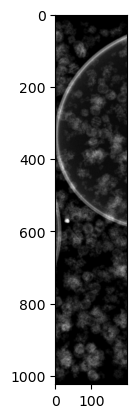

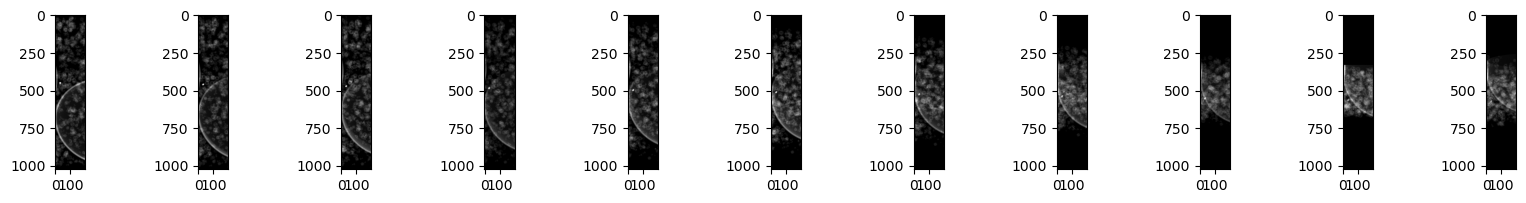

In [ ]:
# imshow full sino gt
plt.figure()
plt.imshow(full_sino_gt[N_view//2], cmap='gray')
plt.show()

fig, axes = plt.subplots(1, 11, figsize=(20, 2))
for i in range(11):
    axes[i].imshow(full_sino_gt[20*i], cmap='gray')
plt.show()

### How to free GPU memory:

* First delete the variable name to that it is considered unused by $\texttt{mempool}$ : type $\texttt{del *variable\_name*}$
* Then free the unused memory with $\texttt{mempool.free\_all\_blocks()}$



In [ ]:
del n
del t
del angle
del t_offset
del t_spec
del n_spec
del theta

mempool.free_all_blocks()

### Prepare de data $y$ 
In order to find an estimator of $x$ such that $$\mathcal{P}_{\theta}\{x\}=y +n, \ \ \ n\sim \mathcal{N}(\boldsymbol{0}, \sigma I_N)$$
> _NOTE : i.i.d Gaussian Noise is a hypothesis that can be strongly questionned._

In [ ]:
print(tilt_series.shape)
load_normalized = False

if load_normalized:
    full_sino_ordered = cp.array(np.load('full_sino_ordered_normalized.npy'), dtype=cp.float32)

else :
    # ordering the sinogram so that it matches the geometry shape
    full_sino_ordered = tilt_series[:, tilt_series.shape[2]//2 -roi :tilt_series.shape[2]//2 + roi , : ]
    # match the geometry order
    full_sino_ordered = np.array(np.swapaxes(full_sino_ordered, 1,2))
    # normalize the sinogram with values between 0 and 1
    #full_sino_ordered = (full_sino_ordered - np.min(full_sino_ordered))/(np.max(full_sino_ordered) - np.min(full_sino_ordered))
    # convert to cupy array and float32
    full_sino_ordered = cp.array(full_sino_ordered, dtype=cp.float32)

full_sino_ordered = -cp.log(full_sino_ordered)
print('Sinogram shape : ',full_sino_ordered.shape)
print('Sinogram dtype : ',full_sino_ordered.dtype)

full_sino_ordered = cp.array(full_sino_gt)

# add noise to the sinogram
mean = cp.mean(full_sino_ordered)
full_sino_ordered = full_sino_ordered + 0.3*mean*cp.random.randn(*full_sino_ordered.shape)

(720, 1024, 1024)


Sinogram shape :  (720, 1024, 200)
Sinogram dtype :  float32


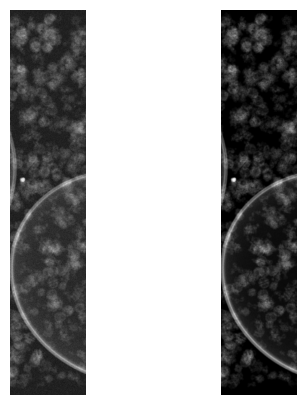

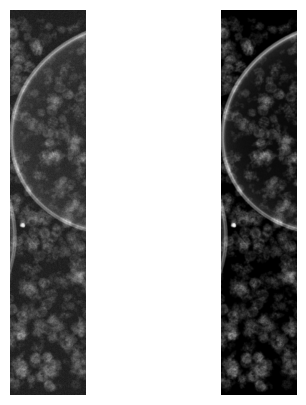

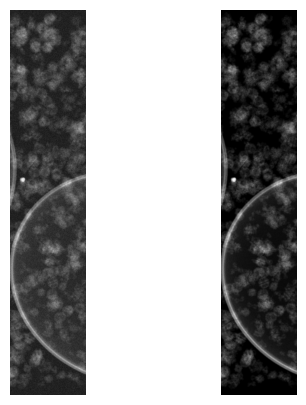

In [ ]:
# imshow different views

#check the match, for synthetic data, between the sinogram and the ground truth projection with MY model

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
axes[0].imshow(full_sino_ordered.get()[0], cmap='gray')
axes[0].axis('off')
axes[1].imshow(full_sino_gt[0], cmap='gray')
axes[1].axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
axes[0].imshow(full_sino_ordered.get()[N_view//2], cmap='gray')
axes[0].axis('off')
axes[1].imshow(full_sino_gt[N_view//2], cmap='gray')
axes[1].axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
axes[0].imshow(full_sino_ordered.get()[-1], cmap='gray')
axes[0].axis('off')
axes[1].imshow(full_sino_gt[-1], cmap='gray')
axes[1].axis('off')
plt.show()

#full_sino_ordered = cp.array(full_sino_gt, dtype=cp.float32)

### Power iteration technique for Lipschitz constant estimation
> The power iteration technique is an iterative algorithm used to estimate the dominant eigenvalue of am operator, which is the Lipschitz constant if the oeprator is linear.
Indeed , for a linear operator $T$,
$$
|| Tx - Ty || = ||T(x-y)|| \leq |\lambda_{max}| \times|| x-y||
$$

In [ ]:
def power_iteration(A, tol: int = 1e-1, maxiter: int = 100):
    # Ideally choose a random vector
    # To decrease the chance that our vector
    # Is orthogonal to the eigenvector
    b_k = cp.random.rand(np.prod(v_shape))
    rel_err = tol*10
    eigenval_max_old = 0

    for i in range(maxiter):

        # calculate the matrix-by-vector product Ab
        b_k1 = A((b_k).reshape(-1))
        # calculate the norm
        b_k1_norm = cp.linalg.norm(b_k1)

        # re normalize the vector
        b_k = b_k1 / b_k1_norm

        # free memory
        del b_k1
        mempool.free_all_blocks()

        eigenval_max = cp.dot(b_k.T, A(b_k)) / cp.dot(b_k.T, b_k) # Rayleigh quotient
        rel_err = cp.abs(eigenval_max - eigenval_max_old)
        eigenval_max_old = eigenval_max
        if i % 10 == 0:
            print('Iteration : ', i, ' | Eigenvalue : ', eigenval_max, ' | Relative error : ', rel_err)

        if rel_err < tol:

            del b_k
            mempool.free_all_blocks()
            return eigenval_max
        
    return eigenval_max

> This value is the precomputed lipschitz constant of the gradient of the data fidelity term of the optimization problem

In [ ]:
L_loss = 197797.48905119288

> Change *False* to *True* to recompute the Lipschitz constant

In [ ]:
compute_lipschitz_loss = False
if compute_lipschitz_loss:
    loss = (0.5 * SquaredL2Norm(dim=full_sino_ordered.size) * op_para_u).grad
    L_loss = power_iteration(loss, tol=1)
    print('L_loss :', L_loss)

### Compute the backprojection
$$
\mathcal P^*[g](x) = \int_{\boldsymbol{\theta}\in\mathbb{S}^{n-1}}
    ~ g_{\boldsymbol{\theta}}(\Pi_{\boldsymbol{\theta}^\perp}\boldsymbol x) d\boldsymbol{\theta}.
$$
> Note : the adjoint is perfectly matched with the forward in our implementation (e.g. not the case with Astra-Toolbox): $$\langle Ax,y \rangle = \langle x,A^*y \rangle$$

In [ ]:
with pxrt.Precision(pxrt.Width.SINGLE):
    I_BP = op_para_u.adjoint(full_sino_ordered.reshape(-1))
    I_BP /= np.max(I_BP)
print('Backprojection dtype : ', I_BP.dtype) 
I_BP_cpu = I_BP.get().reshape(v_shape)
print('Backprojection shape : ', I_BP_cpu.shape)
print('range : ', np.min(I_BP_cpu), np.max(I_BP_cpu))
#compare(I_BP_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:], full_sino_ordered[N_view//2].get(), cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)

Backprojection dtype :  float32
Backprojection shape :  (360, 1024, 200)
range :  0.055169094 1.0


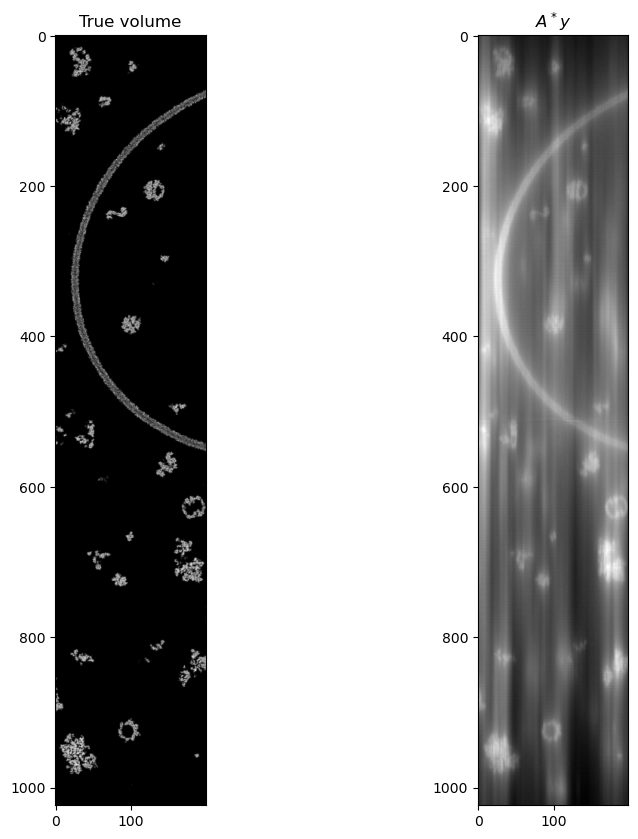

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[1].imshow(I_BP_cpu[v_shape[0]//2 ,v_shape[1]//2-512:v_shape[1]//2+512,:], cmap='gray')
ax[1].set_title('$A^*y$')
ax[0].imshow(gt[gt.shape[0]//2, :, gt.shape[2]//2-roi:gt.shape[2]//2+roi], cmap='gray')
ax[0].set_title('True volume')
plt.show()


---
### Solving pseudo inverse by CGD
We use the $\texttt{.pinv}$ module with [Pyxu](https://pyxu-org.github.io), solving :
$$\hat{x} = \arg\min_{x\in\mathbb{R^N}} \| \mathcal P x - y \|_2^2 + \lambda \|x\|_2^2$$
* $N$ : nb of pixels of the volume
* $y$ : sinogram, $\texttt{full\_sino\_ordered}$ here
* $\hat{x}$ : reconstructed volume, solution of the optimisation problem
* $\lambda$ : $\texttt{damp}$ factor, regularisation term to avoid noise-fitting

In [ ]:
# ========= CGD FOR PSEUDO INVERSERSE REC=========================
print('range of y values : ', np.min(full_sino_ordered.get()), np.max(full_sino_ordered.get()))
range_y = np.max(full_sino_ordered.get()) - np.min(full_sino_ordered.get())
full_sino_ordered_scaled  = full_sino_ordered/range_y
full_sino_ordered = full_sino_ordered_scaled

stop_crit = pxst.MaxIter(30) # number of iterations
with pxrt.Precision(pxrt.Width.SINGLE):
    recon_pinv = op_para_u.pinv(cp.array(full_sino_ordered.reshape(-1)), damp=1, kwargs_fit=dict(stop_crit=stop_crit)).reshape(v_shape)
recon_pinv_cpu = recon_pinv.get()
print('range of values : ', np.min(recon_pinv_cpu), np.max(recon_pinv_cpu))

# remove pinv reconstruction from GPU memory
#del recon_pinv
mempool.free_all_blocks()

range of y values :  -97.80930608916921 829.207866688528
range of values :  -0.0027535676 0.029912518


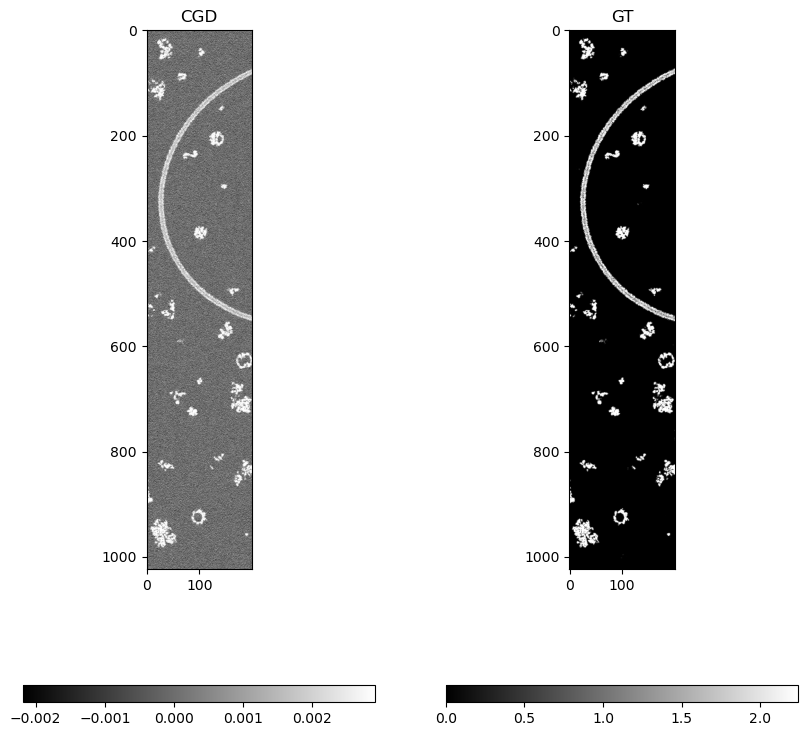

(360, 1024, 200)


In [ ]:
# Slice 0 : we can see missing wedge effect

np.save('rec1_pinv.npy', recon_pinv_cpu) #saving the file to perform separate-volume reconstruction
#compare(recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:], rec_bern_downsampled[:, rec_bern_downsampled.shape[1]//2 - roi:rec_bern_downsampled.shape[1]//2 + roi], cmap="gray", start_mode="horizontal", start_slider_pos=1, height=500)
im1 = recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]

im2 = gt[gt.shape[0]//2, :, gt.shape[1]//2 - roi:gt.shape[1]//2 + roi]
im1 = np.clip(im1, np.mean(im1) - 3.4*np.std(im1), np.mean(im1) + 3.4*np.std(im1))
im2 = np.clip(im2, np.mean(im2) - 3.4*np.std(im2), np.mean(im2) + 3.4*np.std(im2))
fig, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(im1, cmap='gray')
ax[0].set_title('CGD')

# colorbar
plt.colorbar(ax[0].imshow(im1, cmap='gray'), ax=ax[0], orientation='horizontal')
ax[1].imshow(im2, cmap='gray')
ax[1].set_title('GT')

# colorbar
plt.colorbar(ax[1].imshow(im2, cmap='gray'), ax=ax[1], orientation='horizontal')
plt.show()
print(recon_pinv_cpu.shape)

---
### Gradient descent with convergent CRR or WCRR as denoiser prior


**_Optimisation problem_ :** $~~~~~~~~~~~~~~~~~~~$  $\hat{x} = \arg\min_{x\in\mathbb{R^d}} \dfrac{1}{2}\| \mathcal P(x) - y \|_2^2 + \lambda R(x) + \iota_{+}({x})$

> **_NOTE :_** In this example, $R$ is the [Weakly Convex](https://arxiv.org/html/2308.10542v2) regulariser generalised in $3D$, trained with $3D$ CT reconstruction. The structure is such that :
> $$ R : x\in\mathbb{R}^d \mapsto \sum_{k=1}^{d \times N_c} \psi_k(w_k^T~x)$$
> where the $(\psi_k)_k$ are potential functions, and $(w_k)_k \in \mathbb{R}^d$ are the filter versions. We can then compute :
> $$ \nabla R : x \mapsto W^T \varphi (W~x)$$
> where $\varphi$ is the pointwise activation function derived from the $(\psi_k)_k$.

In [ ]:
device = "cuda:0"
fname = 'WCRR-CNN_8_channels_3_kernelsize_15_fwsteps_3_bwsteps'
model = utils.load_model(fname, device=device)
model.eval()
model.to(device)
print(" **** Updating the Lipschitz constant **** ")
model.conv_layer.L = torch.tensor(22.9256).to(device) # For 8 channels Weakly
#model.conv_layer.L = torch.tensor(50.0694).to(device) # For 16 channels Weakly
#model.conv_layer.L = torch.tensor(144.4009).to(device) # For 16 channels Weakly

#model.conv_layer.L = torch.tensor(83.1117).to(device) # For 32 channels
#model.conv_layer.L = torch.tensor(61.6555).to(device) # For 16 channels
#model.conv_layer.L = torch.tensor(30.2030).to(device) # For 8 channels

#sn_pm = model.conv_layer.spectral_norm(mode="power_method", n_steps=500) # compute lipschiitz constant
L_R = model.nonlinearity.slope_max(model.get_mu())*model.get_mu()
print(float(L_R))

Multi convolutionnal layer:  {'num_channels': [1, 8, 8], 'size_kernels': [3, 3]}
 **** Updating the Lipschitz constant **** 
32.33198547363281


In [ ]:
loss = 0.5 * SquaredL2Norm(dim=full_sino_ordered.size).asloss(full_sino_ordered.ravel()) * op_para_u
# normalize the loss
loss_nrmzd = loss/1e5
L_loss_nrmzd = L_loss/1e5

iter = 100
x = recon_pinv.reshape(-1) #I_BP
print('range : ', np.min(x), np.max(x))
lambda_denoiser = 0.009
mus = np.logspace(np.log10( 100 ), np.log10( 1 ), iter, base=10, dtype=np.float32) #decreasing noise level, see Ulugbek Bologna

sigma_ = 0.2
sigma = torch.tensor(sigma_).repeat(1,1,1,1,1).to(device)
denoiser_op = from_torch(lambda x : model.grad(x.reshape(1, 1, v_shape[0], v_shape[1], v_shape[2]), sigma=sigma).reshape(-1), 
                            shape=(np.prod(v_shape), np.prod(v_shape)))
rel_err_curve = np.zeros(iter)
cost_curve = np.zeros(iter)

with torch.no_grad():
    with pxrt.Precision(pxrt.Width.SINGLE):
        for i in tqdm.tqdm(range(iter)):

            x_next = x - (lambda_denoiser*denoiser_op(x) + loss_nrmzd.grad(x))/(lambda_denoiser*L_R + L_loss_nrmzd)
            #cost_curve[i] = float(loss_nrmzd(x))
            #print('range : ', np.min(x), np.max(x))

            #x_next = cp.clip(x_next, 0, 1)

            res = cp.linalg.norm(x_next - x)/cp.linalg.norm(x)
            rel_err_curve[i] = res

            x = x_next

range :  -0.0027535676 0.029912518


100%|██████████| 100/100 [04:44<00:00,  2.85s/it]


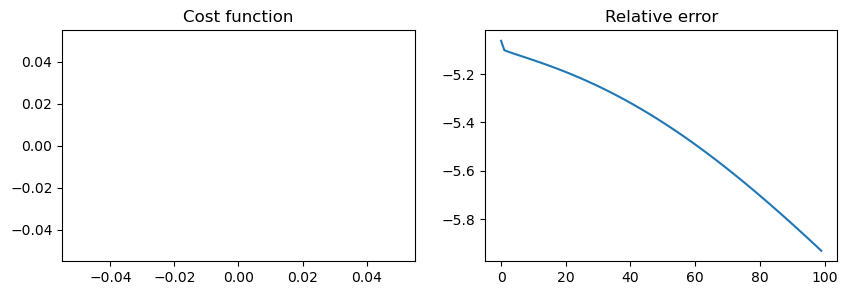

In [ ]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(np.log(cost_curve))
plt.title('Cost function')
plt.subplot(1, 2, 2)
plt.plot(np.log(rel_err_curve))
plt.title('Relative error')
plt.show()

recon_wcrr = x  
recon_wcrr = recon_wcrr.reshape(v_shape)
recon_wcrr= recon_wcrr.get()

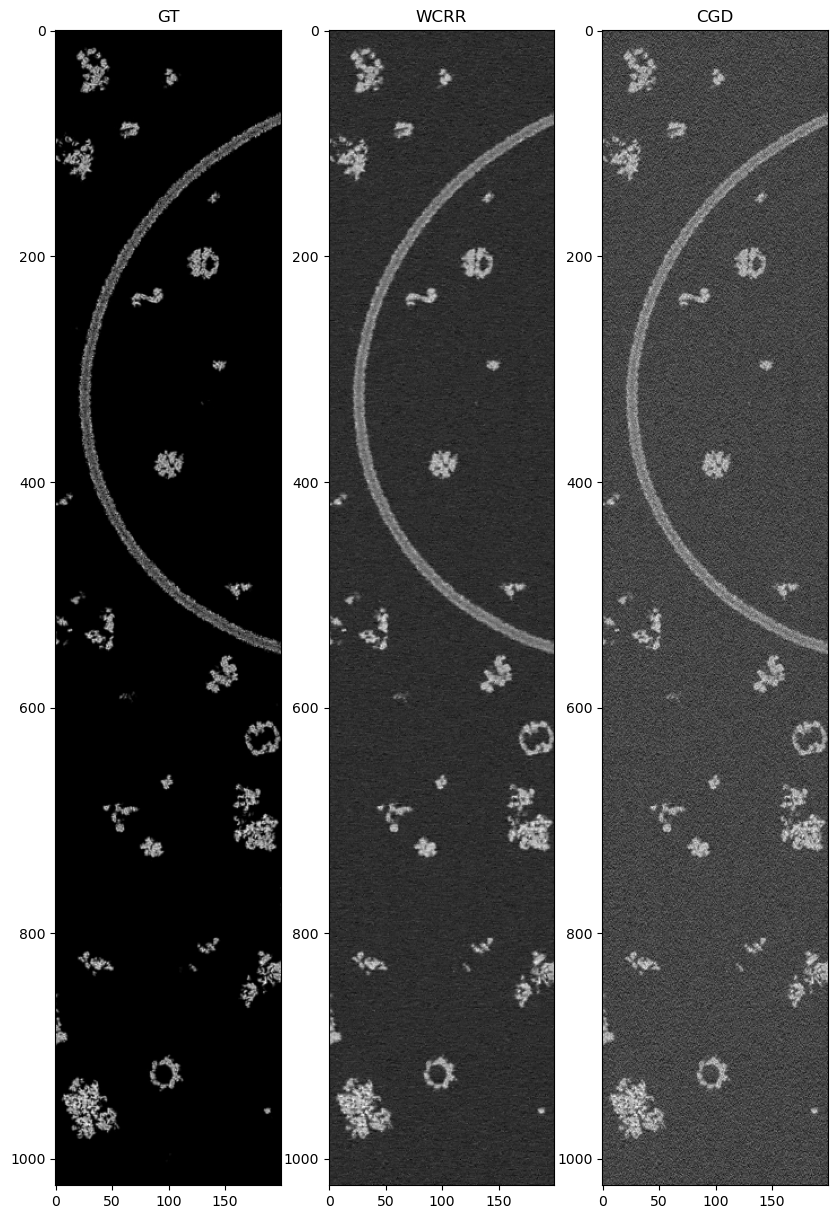

In [ ]:
im1 = recon_wcrr[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]
im2 = recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]
#im1 = np.clip(im1, np.mean(im1) - 3*np.std(im1), np.mean(im1) + 3*np.std(im1))
#im2 = np.clip(im2, np.mean(im2) - 3*np.std(im2), np.mean(im2) + 3*np.std(im2))
im3 = gt[gt.shape[0]//2, :, gt.shape[1]//2 - roi:gt.shape[1]//2 + roi]
#compare(im1, im2, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)
fig, ax = plt.subplots(1,3, figsize=(10,15), dpi=100)
ax[0].imshow(im3, cmap='gray')
ax[0].set_title('GT')
ax[1].imshow(im1, cmap='gray')
ax[1].set_title('WCRR')
ax[2].imshow(im2, cmap='gray')
ax[2].set_title('CGD')

plt.show()

## Performing the full volume reconstruction on GPU. 

> Iterations of simple Proximal Gradient Descent. Power iterations gives us the Lipschitz constant of the gradient of the data fidelity term $L_{model}$ and the regulariser $L_R$. The total lipschitz constant is upper-bounded by $L = L_{model} + \lambda L_R $.

$$x_{k+1} = \text{prox}_{\iota_+}(~ x_k - \dfrac{1}{L} \left(~\nabla J(x_k) + \lambda \nabla R(x_k)~\right)~)$$

The reconstruction is done with slices that fit the GPU, one by one, with an overlap to deal with limit conditions properly.

In [21]:
recon_wcrr_full = np.zeros((width_volume,1536,1024-6*10))

for k in range(6):
    # take slices of size 2*roi, but with overlap of 10 pixels to avoid artifacts
    full_sino_ordered = tilt_series[:, 2*k*(roi-10) : 2*k*(roi-10) + 2*roi , : ]
    #full_sino_ordered = tilt_series[:, 2*k*roi :2*(k+1)*roi , : ] 
    full_sino_ordered = np.array(np.swapaxes(full_sino_ordered, 1,2))
    full_sino_ordered = cp.array(full_sino_ordered, dtype=cp.float32)

    full_sino_ordered_scaled  = full_sino_ordered / 20
    full_sino_ordered = full_sino_ordered_scaled
    
    print(f'data ready for slice {k}')

    print(full_sino_ordered.shape)
    with pxrt.Precision(pxrt.Width.SINGLE):
        I_BP = op_para_u.adjoint(full_sino_ordered.reshape(-1))
        I_BP /= np.max(I_BP)

    loss = 0.5 * SquaredL2Norm(dim=full_sino_ordered.size).asloss(full_sino_ordered.ravel()) * op_para_u
    # normalize the loss
    loss_nrmzd = loss/1e5
    L_loss_nrmzd = L_loss/1e5

    iter = 100
    x = I_BP
    lambda_denoiser = 0.25
    #mus = np.logspace(np.log10( 40 ), np.log10( 1 ), iter, base=10, dtype=np.float32)

    sigma_ = 3.75
    sigma = torch.tensor(sigma_).repeat(1,1,1,1,1).to(device)
    denoiser_op = from_torch(lambda x : model.grad(x.reshape(1, 1, v_shape[0], v_shape[1], v_shape[2]), sigma=sigma).reshape(-1), 
                                shape=(np.prod(v_shape), np.prod(v_shape)))

    with torch.no_grad():
        with pxrt.Precision(pxrt.Width.SINGLE):
            for i in tqdm.tqdm(range(iter)):

                x_next = x - (lambda_denoiser*denoiser_op(x) + loss_nrmzd.grad(x))/(lambda_denoiser*L_R + L_loss_nrmzd)
                #print('range : ', np.min(x), np.max(x))
                x_next = cp.clip(x_next, 0, 1)
                res = cp.linalg.norm(x_next - x)/cp.linalg.norm(x)
                x = x_next

    recon_wcrr_full[:,:,k*(roi-10):(k+1)*(roi-10)] = x.reshape(v_shape).get()[:, :, 5:-5]

np.save('rec_wcrr.npy', recon_wcrr_full) 

data ready for slice 0
(55, 2048, 340)


100%|██████████| 100/100 [01:15<00:00,  1.32it/s]


data ready for slice 1
(55, 2048, 340)


100%|██████████| 100/100 [01:18<00:00,  1.27it/s]


data ready for slice 2
(55, 2048, 340)


...

100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


data ready for slice 4
(55, 2048, 340)


100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


data ready for slice 5
(55, 2048, 340)


100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


In [22]:
recon_wcrr_full = np.load('rec_wcrr.npy')
full_shape = recon_wcrr_full.shape

(1024, 964)
(2048, 1928)


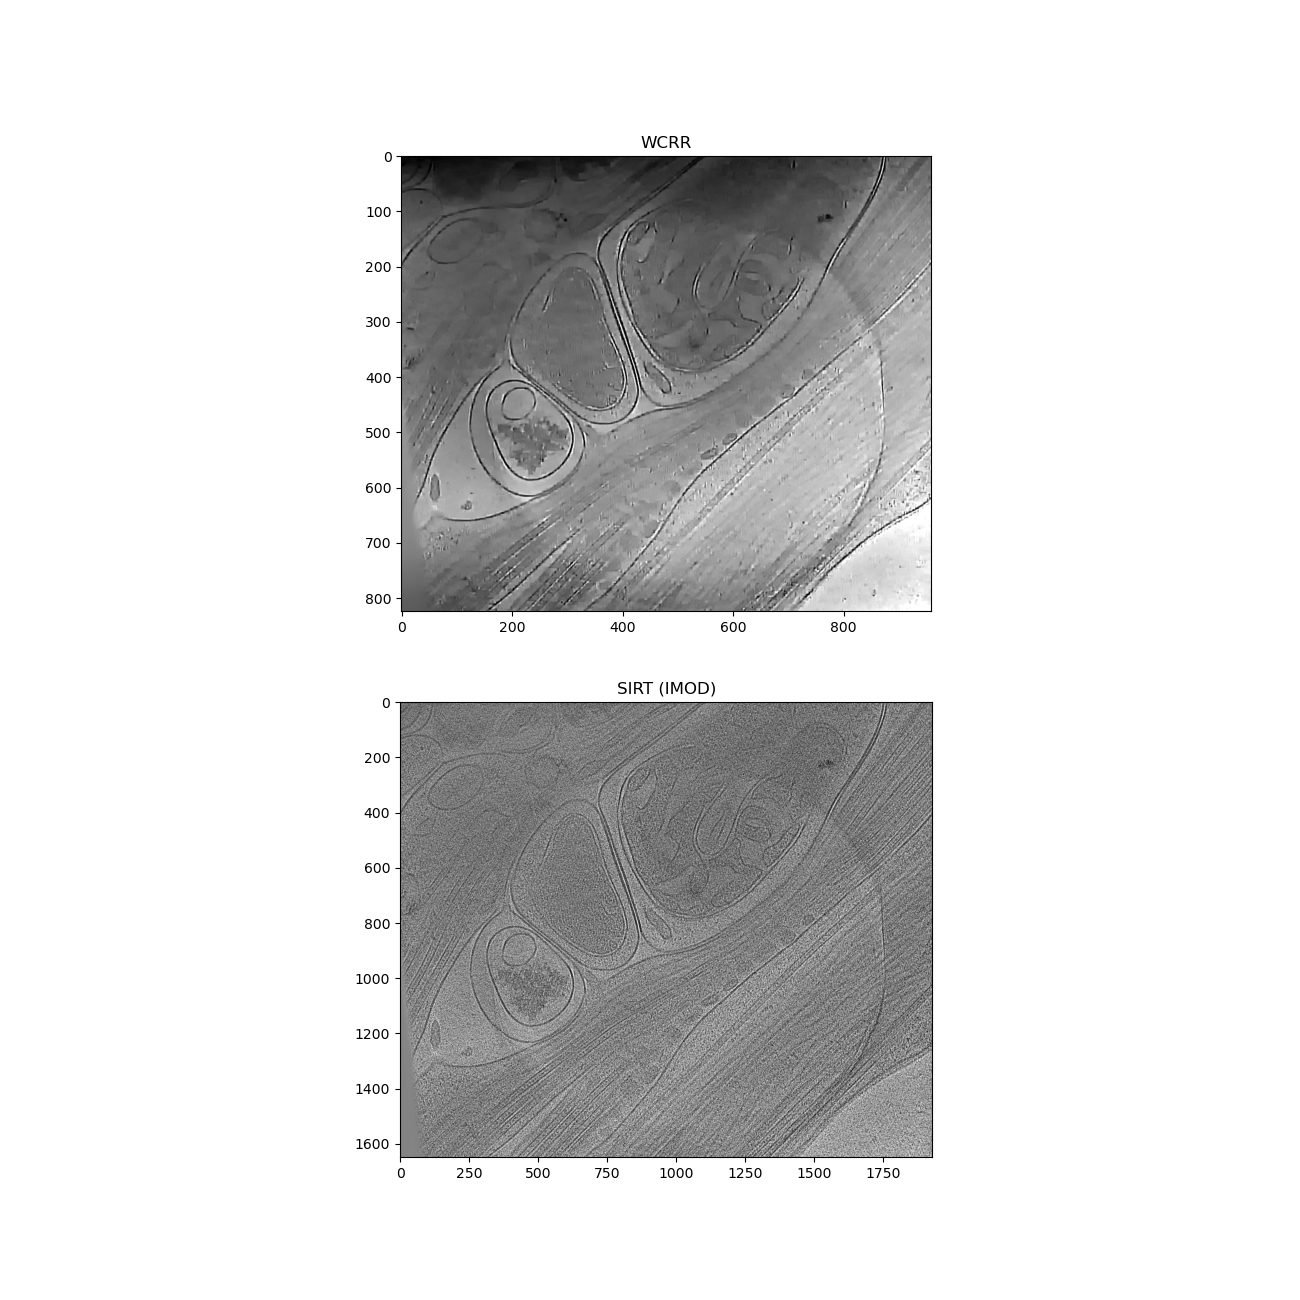

In [26]:
print(recon_wcrr_full[full_shape[0]//2, full_shape[1]//2-512:full_shape[1]//2+512,:].shape)
print(rec_bern_downsampled[:, :-120].shape)

im1 = recon_wcrr_full[full_shape[0]//2, full_shape[1]//2-412:full_shape[1]//2+412,:]
im2 = rec_bern_downsampled[200:-200, 5:-115]
mean1 = np.mean(im1)
mean2 = np.mean(im2)
vmin1 = mean1 - 2.5*np.std(im1)
vmax1 = mean1 + 2.5*np.std(im1)
vmin2 = mean2 - 2.5*np.std(im2)
vmax2 = mean2 + 2.5*np.std(im2)
im1 = np.clip(im1, vmin1, vmax1)
im2 = np.clip(im2, vmin2, vmax2)
#compare(im1, im2, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=700)
fig, ax = plt.subplots(2,1, figsize=(13,13))
ax[0].imshow(im1[:, :-5], cmap='gray')
ax[0].set_title('WCRR')
ax[1].imshow(im2, cmap='gray')
ax[1].set_title('SIRT (IMOD)')
plt.show()

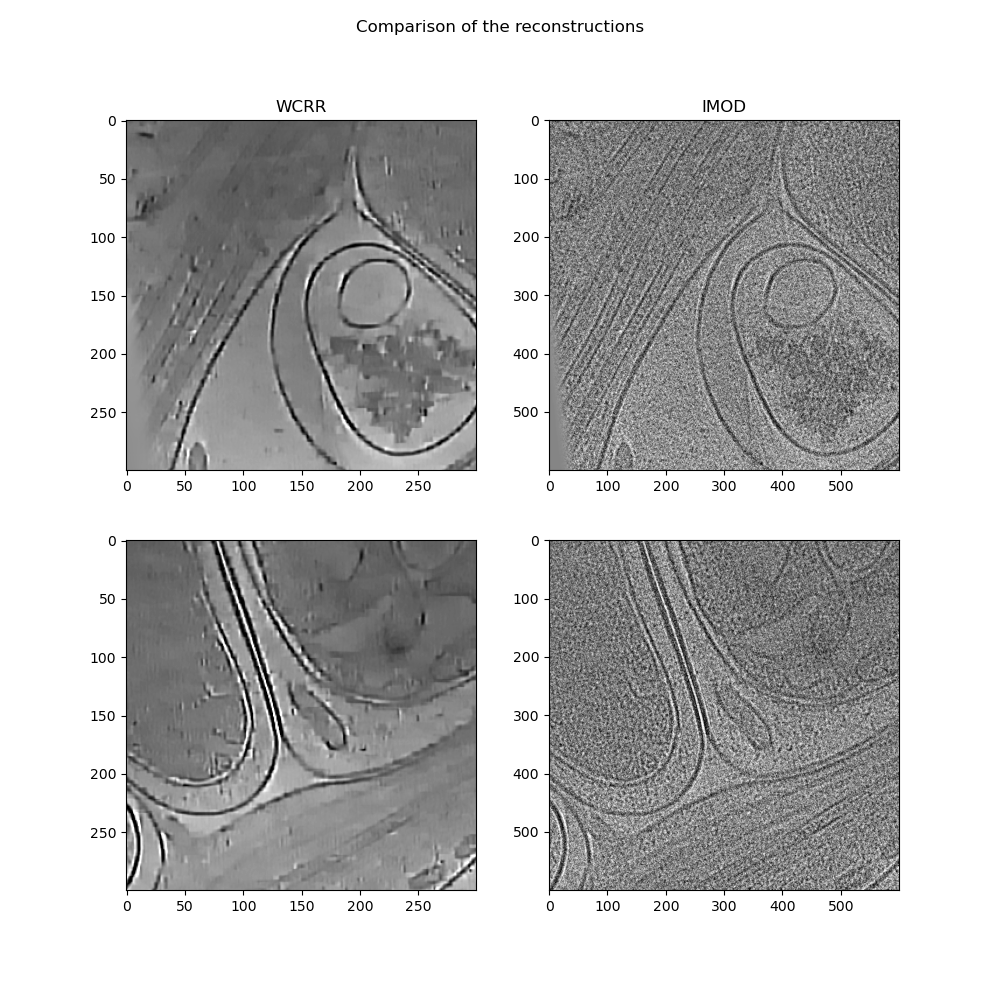

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Comparison of the reconstructions')
axs[0][0].imshow(im1[300:600, :300], cmap='gray', vmin=vmin1, vmax=vmax1)
axs[0][0].set_title('WCRR')
axs[0][1].imshow(im2[600:1200, :600], cmap='gray', vmin=vmin2, vmax=vmax2)
axs[0][1].set_title('IMOD')
axs[1][0].imshow(im1[250:550, 300:600], cmap='gray', vmin=vmin1, vmax=vmax1)
axs[1][1].imshow(im2[500:1100, 600:1200], cmap='gray', vmin=vmin2, vmax=vmax2)
plt.show()

In [25]:
grad_cpu = Gradient(
    arg_shape=v_shape,
    diff_method="fd",
    mode = 'wrap',
    scheme="central",
    accuracy=2,
    gpu = False,
    sampling = [1, 1, 1]
)

alg_compensation = True
if alg_compensation:
    lambda_denoiser = 10
    iter = 40
    #x = I_BP
    x = cp.array(recon_pinv_cpu, dtype=cp.float32).reshape(-1)
    with torch.no_grad():
        with pxrt.Precision(pxrt.Width.SINGLE):
            for i in range(iter):
                x_next = x - (lambda_denoiser*model_crr.grad(x) + loss_nrmzd.grad(x))/(lambda_denoiser*L_R + L_loss_nrmzd)
                #update only low frequencies
                grad_map = grad_cpu(x.get()).reshape(3, *v_shape)
                grad_map_intensity = np.linalg.norm(grad_map, axis = 0)
                grad_map_n = grad_map_intensity/np.max(grad_map_intensity)
                grad_map_n = cp.array((grad_map_n)**(0.3), dtype=cp.float32).reshape(-1) 
                                     
                x_next = grad_map_n * x + (1-grad_map_n) * x_next
                del grad_map_n
                mempool.free_all_blocks()   
                #x_next = cp.clip(x_next, 0, 1)
                res = cp.linalg.norm(x_next - x)/cp.linalg.norm(x)
                print(i, res)
                x = x_next

    recon_crr = x  
    recon_crr = recon_crr.reshape(v_shape)
    recon_crr= recon_crr.get()

range before:  -0.5631725 0.70699894
0 0.0102752885
range before:  -0.56276655 0.7063881
1 0.009970383
range before:  -0.5623591 0.7057821
2 0.00963466
range before:  -0.56194973 0.70518225
3 0.009301989
range before:  -0.5615385 0.7045877
4 0.008984757
range before:  -0.5614541 0.7039979
5 0.008685857
range before:  -0.5616391 0.7034194
6 0.008405444
range before:  -0.56182456 0.7029659
7 0.008142554
range before:  -0.5620104 0.7029946
8 0.00789586
range before:  -0.5621964 0.7030228
9 0.0076638297
range before:  -0.56238216 0.7030512
10 0.007444859
range before:  -0.5625683 0.70307994
11 0.007237391
range before:  -0.56275487 0.7031689
12 0.0070401146
range before:  -0.5629421 0.70332706
13 0.0068519744
range before:  -0.56313044 0.7034846
14 0.0066721146
range before:  -0.5633201 0.70364165
15 0.006499795
range before:  -0.56351125 0.7037988
16 0.0063343965
range before:  -0.5637039 0.7039563
17 0.006175411
range before:  -0.5638979 0.70411444
18 0.006022536
range before:  -0.564093


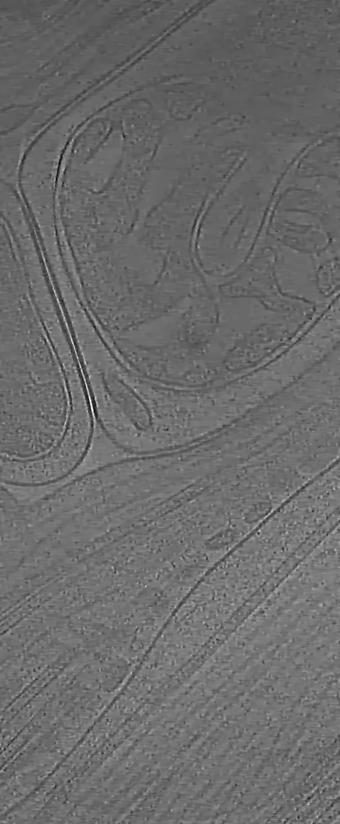
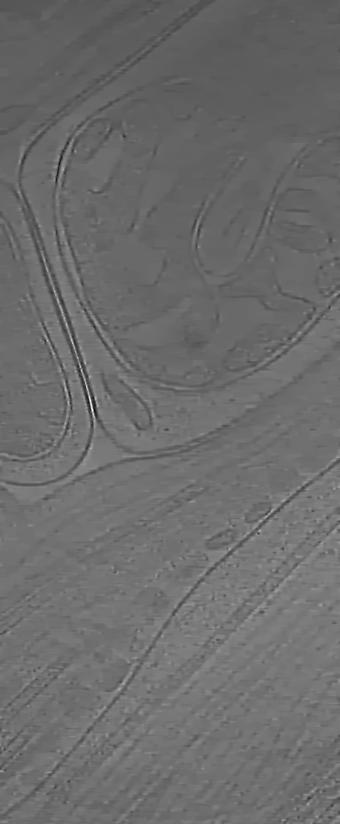

In [26]:
compare(recon_crr[v_shape[0]//2,v_shape[1]//2-412:v_shape[1]//2+412,:], recon_wcrr[v_shape[0]//2,v_shape[1]//2-412:v_shape[1]//2+412,:], cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)

## Testing grad dependant contribution


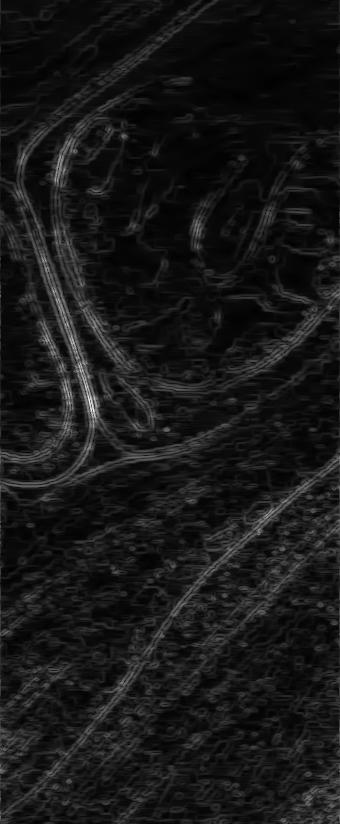
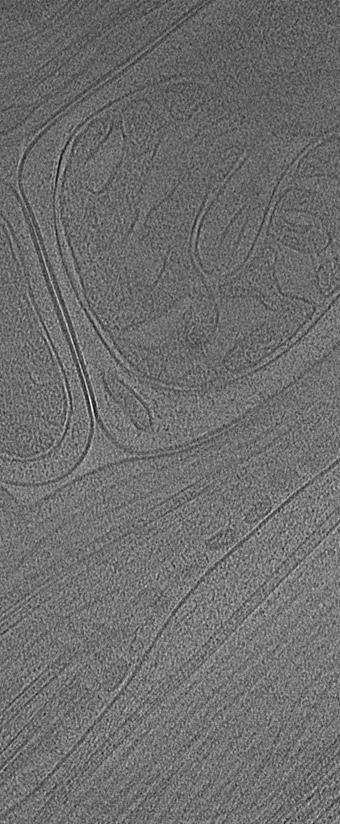

In [52]:
grad_map = grad_cpu(recon_crr.reshape(-1)).reshape(3, *v_shape)
grad_map_intensity = np.linalg.norm(grad_map, axis = 0)
grad_map_n = grad_map_intensity/np.max(grad_map_intensity)
grad_map_n = np.sqrt(grad_map_n)
compare(grad_map_n[v_shape[0]//2, v_shape[1]//2-412:v_shape[1]//2+412,:], recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-412:v_shape[1]//2+412,:], cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)


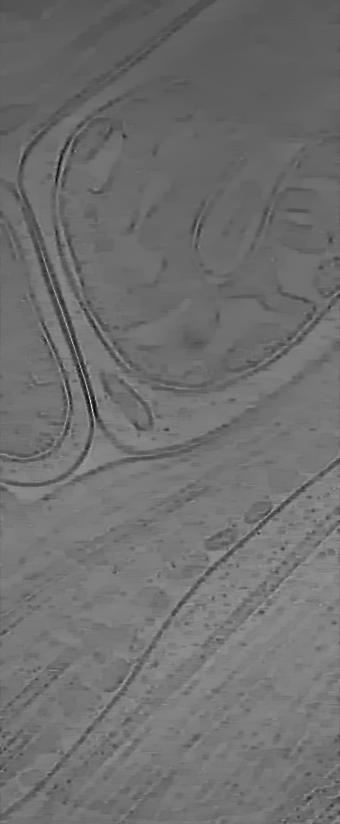
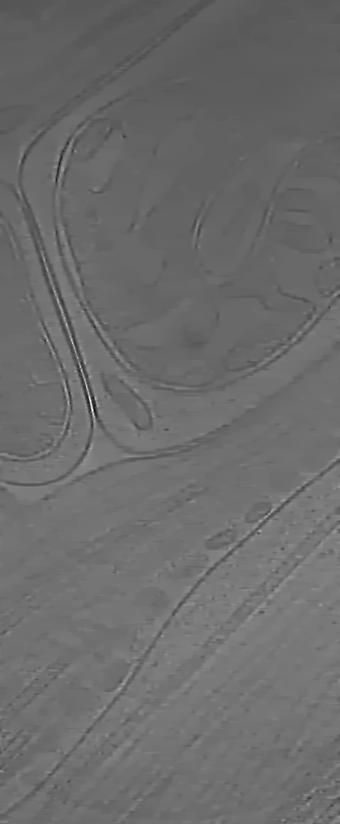

In [51]:
lambda_comp = 0.2
final_res = lambda_comp*grad_map_n * recon_pinv_cpu[v_shape[0]//2, :, :] + (1-lambda_comp)*(1-grad_map_n) * recon_crr[v_shape[0]//2, :, :]
compare(final_res[v_shape[1]//2-412:v_shape[1]//2+412,:], recon_crr[v_shape[0]//2,v_shape[1]//2-412:v_shape[1]//2+412,:], cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)

## More advanced reconstruction techniques
$$\hat{x} = \argmin_{x\in\mathbb{R}^N}\mathcal{F}(Ax,y) + \lambda\mathcal{R}(x), \ \ \ \ \lambda>0$$
Since noise is supposed to be Gaussian i.i.d., 
$$
\mathcal{F}(Ax,y) = \|y-Ax\|_2^2
$$
* Total variation prior : $
\mathcal{R}(x) = \text{TV}(x) = \|\nabla x\|_1$ 

$\text{TV}(x)$ is not differentiable. We can either do a Proximal Gradient Descent (PGD) since $\text{TV}(x)$ is proximable, or a simple gradient descent, using the convex Moreau-enveloppe defined as : $$M_{\lambda f}(v) = \inf_{x\in\mathcal{X}} \left(f(x) + \frac{1}{2\lambda} \|x - v\|_2^2\right).$$
Knowing the Moreau-enveloppe of a proximal function, we can replace the proximal step of the PGD using the relation :
$$
\nabla M_{\lambda f}(x) = \frac{1}{\lambda} (x - \mathrm{prox}_{\lambda f}(x))
$$



In [32]:
grad = Gradient(
arg_shape=v_shape,
diff_method="fd",
mode = 'wrap',
scheme="central",
accuracy=2,
gpu = True,
sampling = [1, 1, 1]
)

class TVFunc(ProxFunc):
    r"""
    TODO
    """

    def __init__(self,
                arg_shape,
                isotropic: bool = True,
                finite_diff_kwargs: dict = dict(),
                prox_init_kwargs: dict = dict(show_progress=False),
                prox_fit_kwargs: dict = dict(),
                ):
        r"""
        Parameters
        ----------
        arg_shape: pyct.NDArrayShape
            Shape of the input array.
        isotropic: bool
            Isotropic or anisotropic TV (Default: isotropic).
        """
        
        N_dim = len(arg_shape)

        super().__init__(shape=(1, arg_shape[0]*arg_shape[1]*arg_shape[2]))
        
        self._arg_shape = arg_shape
        
        finite_diff_op = grad
        
        finite_diff_op.lipschitz= L_grad
                
        self._finite_diff_op = finite_diff_op
        
        if isotropic:
            self._norm = L21Norm(arg_shape=(N_dim, *arg_shape))
        
        #self._norm = L1Norm(dim=finite_diff_op.codim)
        self._prox_init_kwargs = prox_init_kwargs
        self._prox_fit_kwargs = prox_fit_kwargs

        
    def apply(self, arr):
        return self._norm(self._finite_diff_op(arr))

    def prox(self, arr, tau = 0.05):
        ls = 1 / 2 * SquaredL2Norm(dim=arr.size).argshift(arr)
        
        ls.diff_lipschitz = 1.
        slv = CV(f=ls, h=tau * self._norm, K=self._finite_diff_op, verbosity = 2)
        slv.fit(x0=arr.copy(), stop_crit = pxst.RelError(eps=1e-90, var="x", f=None, norm=2, satisfy_all=True) | pxst.MaxIter(10))
        return slv.solution().reshape(arr.shape)

In [33]:
# ================ GD with smoothed TV prior ==============================
huber_norm = L1Norm(grad.shape[0]).moreau_envelope(0.0000000000001)
loss_tv = huber_norm * grad 

In [34]:
loss_tv.diff_lipschitz = power_iteration(loss_tv.grad, tol=1)
print('L_loss_tv :', loss_tv.diff_lipschitz)

Iteration :  0  | Eigenvalue :  17656.33835587072  | Relative error :  17656.33835587072
Iteration :  10  | Eigenvalue :  20596.36660627971  | Relative error :  27.194348263397842
Iteration :  20  | Eigenvalue :  20665.590137296942  | Relative error :  1.194595089818904
L_loss_tv : 20666.469712458173


In [35]:
L_tv = 6*2953.5171893540096

(Normalize the initial guess before running the algorithm)

In [36]:
I_BP /= cp.max(I_BP)
I_BP -= cp.min(I_BP)

The total loss ($\texttt{loss\_tot}$) is the sum of the $L_2$ loss and TV Moreau-enveloppe

In [37]:
mempool.free_all_blocks()

# ================ GD with smoothed TV prior ==============================
loss = 0.5 * SquaredL2Norm(dim=full_sino_ordered.size).asloss(full_sino_ordered.ravel()) * op_para_u

lambda_tv = 100
lambda_data_fidelity = 1

loss_tot = lambda_data_fidelity*loss + lambda_tv*loss_tv
loss_tot.diff_lipschitz = (L_loss + lambda_tv*L_tv)

stop_crit = pxst.RelError(
    eps=1e-99,
    var="x",
    f=None,
    norm=2,
    satisfy_all=True,
) | pxst.MaxIter(25)

print('Diff Lipscitz of the cost function : ', loss_tot.diff_lipschitz)
print(1/loss_tot.diff_lipschitz)
#solver = PD3O(f=loss, g = None, h= l21, K=grad, show_progress=True, verbosity = 1) #before beta = 1e5
solver = PGD(f=loss_tot, g = None, show_progress=True, verbosity = 1) #before beta = 1e5
solver.fit(x0=I_BP.reshape(-1), stop_crit=stop_crit, acceleration=False)  # Solving the optimization problem
recon_pd = solver.solution().squeeze()
recon_pd = recon_pd.reshape(v_shape)
recon_pd= recon_pd.get()

Diff Lipscitz of the cost function :  1984716.9106834903
5.038501937566619e-07
INFO -- [2024-09-11 17:12:52.532884] Iteration 0
	iteration: 0
	RelError[x]: 0.0
	N_iter: 1.0


ERROR -- [2024-09-11 17:12:54.576266] Something went wrong -> EXCEPTION RAISED
Traceback (most recent call last):
  File "/home/haouchat/miniconda3/envs/pyxu/lib/python3.11/site-packages/pyxu/abc/solver.py", line 618, in _step
    self.m_step()
  File "/home/haouchat/miniconda3/envs/pyxu/lib/python3.11/site-packages/pyxu/opt/solver/pgd.py", line 181, in m_step
    z = pxu.copy_if_unsafe(self._f.grad(y))
                           ^^^^^^^^^^^^^^^
  File "/home/haouchat/miniconda3/envs/pyxu/lib/python3.11/site-packages/pyxu/runtime/_runtime.py", line 189, in wrapper
    out = func(**func_args)
          ^^^^^^^^^^^^^^^^^
  File "/home/haouchat/miniconda3/envs/pyxu/lib/python3.11/site-packages/pyxu/abc/arithmetic.py", line 939, in grad
    out += self._rhs.grad(arr)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/haouchat/miniconda3/envs/pyxu/lib/python3.11/site-packages/pyxu/runtime/_runtime.py", line 189, in wrapper
    out = func(**func_args)
          ^^^^^^^^^^^^^^^^^
  File "/home/haou

[2024-09-11 17:12:54.576266] Something went wrong -> EXCEPTION RAISED
More information: /tmp/pyxu_0n_mwer3/solver.log.



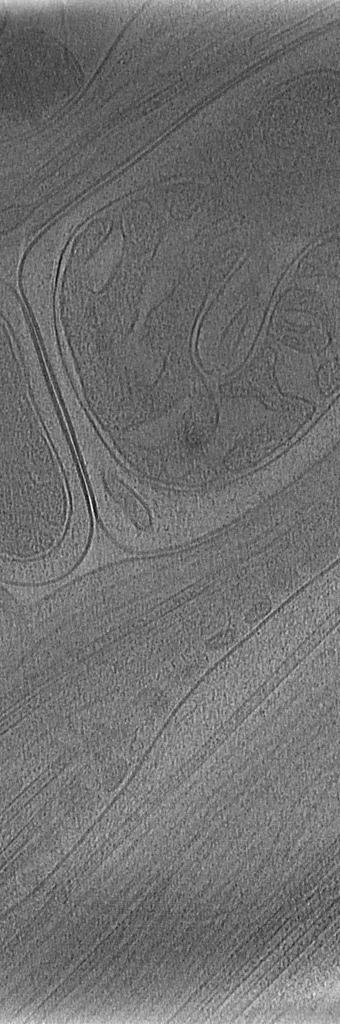
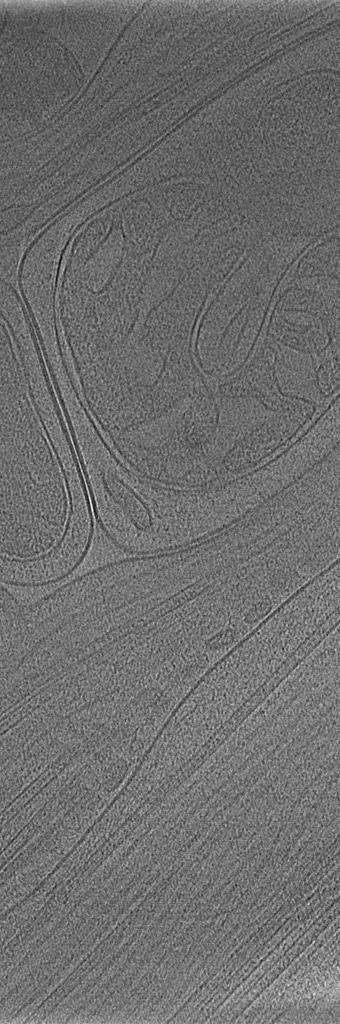

In [23]:
rec = recon_pd[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]
ibp = I_BP[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]

compare(rec, recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:], cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)

* Plug-And-Play (PnP) algorithm, using a denoiser $D$ instead of the prox, or $(I_d - D)$ instead of the gradient

Here, we try the median filter, that denoises and smoothens the solution.
In its proximal form, a typical PnP algorithm can be represented by:

$$
f^{k+1} = \text{Denoiser}_{\sigma}(f^k - \tau \nabla F(f^k)),
$$
where $\nabla F(x)$ is the gradient term ensuring data fidelity.

In differential form, influenced by the regularization by denoising ([RED](https://arxiv.org/abs/1611.02862)) framework,
the equation can be expressed as:

$$
f^{k+1} = f^k - \tau \left[\nabla F(f^k) + \lambda(f^k- \text{Denoiser}_{\sigma}(f^k))\right],
$$
where $\lambda$ encodes the PnP prior strength. 

> **_NOTE:_** Tweedie's formula tells us that when $\text{Denoiser}_{\sigma}$ is an MMSE Gaussian denoiser, we should
> choose $\lambda = 1/\sigma$ (where $\sigma$ is the noise level). The term $\frac{1}{\sigma}(f^k-
> \text{Denoiser}_{\sigma}(f^k))$ can then be understood as the    approximate score (gradient) of the distribution of
> natural images convolved with a Gaussian with standard deviation $\sigma$. 

In [24]:
from cupyx.scipy.ndimage import median_filter

#from scipy.ndimage import median_filter

def denoiser(arr, arg_shape, wsize):
    arr = arr.reshape(arg_shape)
    return median_filter(arr, size=wsize, mode='mirror').reshape(-1)

class MedianFilterPnP(pxa.ProxDiffFunc):
    def __init__(self, arg_shape, wsize):
        super().__init__((1, arg_shape[0]*arg_shape[1]*arg_shape[2]))
        self._arg_shape = arg_shape
        self.wsize= wsize
        self.diff_lipschitz = 1

    def apply(self, arr):
        return NotImplemented  # PnP priors are implicit: they do not have an apply method!

    def grad(self, arr):
        return (arr - denoiser(arr, self._arg_shape, self.wsize))  # Differential form

    def prox(self, arr, tau=None):  # `tau`` is not used since this is not a proper proximal operator.
        return denoiser(arr, self._arg_shape, self.wsize)  # Proximal form

medpnp = MedianFilterPnP(v_shape, (3,3,3))

To use differential form, use one smooth term to do Gradient Descent (GD), \
with 
$\texttt{f=composite\_smooth}$.
Otherwise, use PGD with \
$\texttt{f=loss}$ and $\texttt{g=medpnp}$

In [25]:
stop_crit = pxst.RelError(
    eps=1e-5,
    var="x",
    f=None,
    norm=2,
    satisfy_all=True,
) | pxst.MaxIter(7) # 50 before 200 15 before

lambda_pnp = 2e-5
lambda_denoiser = 2


composite_smooth = lambda_pnp*loss + lambda_denoiser*medpnp 
composite_smooth.diff_lipschitz = lambda_pnp*L_loss 

solver = PGD(f=composite_smooth, g = None, show_progress=True, verbosity = 1) #before beta = 1e5
solver.fit(x0=(I_BP).reshape(-1), stop_crit=stop_crit)  # Solving the optimization problem
recon_pnp = solver.solution().squeeze()
recon_pnp = recon_pnp.reshape(v_shape)
recon_pnp= recon_pnp.get()

INFO -- [2024-05-29 14:54:47.117361] Iteration 0
	iteration: 0
	RelError[x]: 0.0
	N_iter: 1.0
INFO -- [2024-05-29 14:54:48.234083] Iteration 1
	iteration: 1
	RelError[x]: 0.9750518600831457
	N_iter: 2.0
INFO -- [2024-05-29 14:54:49.256146] Iteration 2
	iteration: 2
	RelError[x]: 0.5351965207201099
	N_iter: 3.0
INFO -- [2024-05-29 14:54:50.280316] Iteration 3
	iteration: 3
	RelError[x]: 0.34253281577145384
	N_iter: 4.0
INFO -- [2024-05-29 14:54:51.302726] Iteration 4
	iteration: 4
	RelError[x]: 0.2581516952659439
	N_iter: 5.0
INFO -- [2024-05-29 14:54:52.323584] Iteration 5
	iteration: 5
	RelError[x]: 0.20703605584405546
	N_iter: 6.0
INFO -- [2024-05-29 14:54:53.342303] Iteration 6
	iteration: 6
	RelError[x]: 0.170648497982018
	N_iter: 7.0
INFO -- [2024-05-29 14:54:54.359392] Iteration 7
	iteration: 7
	RelError[x]: 0.14319426074511699
	N_iter: 8.0
INFO -- [2024-05-29 14:54:54.360341] Stopping Criterion satisfied -> END



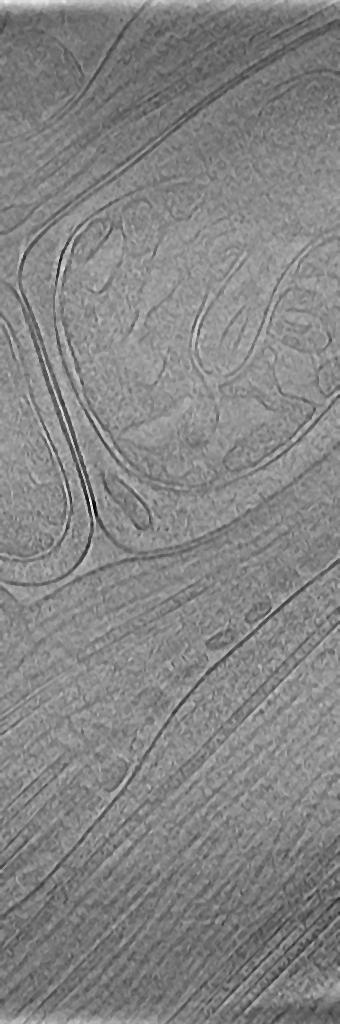
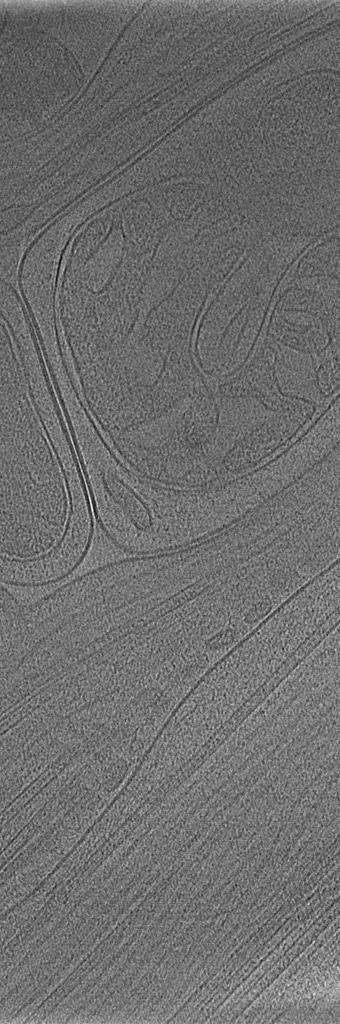

In [26]:
rec_pnp = recon_pnp[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]
rec_pnp /= np.max(rec_pnp)
recon_pd /= np.max(recon_pd)
compare(rec_pnp, recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:], cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)

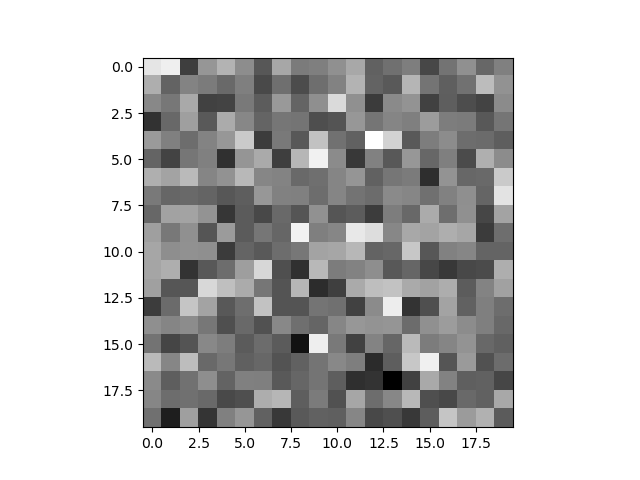

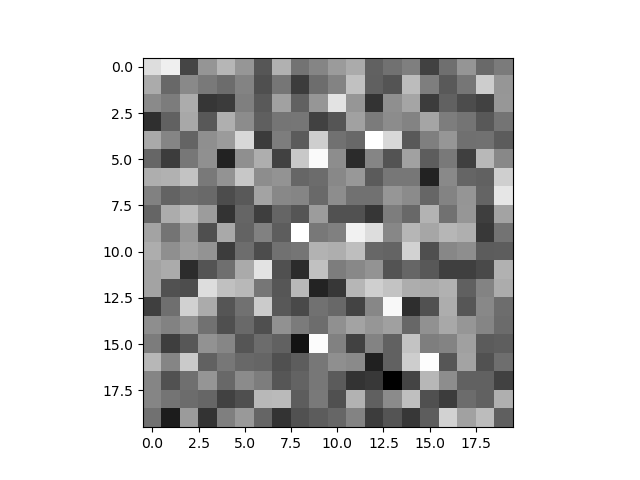

In [18]:
# 3D phantom 
with torch.no_grad():
    test = torch.randn(1, 1, 20, 20, 20).to(device)
    res = test - model.grad(test, sigma=torch.tensor(10.0).repeat(1,1,1,1,1).to(device))

plt.figure()
plt.imshow(test[0,0,10].cpu().numpy())
plt.figure()
plt.imshow(res[0,0,10].cpu().numpy())
plt.show()

In [176]:
w = 512
rec_ = recon_pinv_cpu[:,:,:]
print(rec_.shape)


(200, 1536, 340)


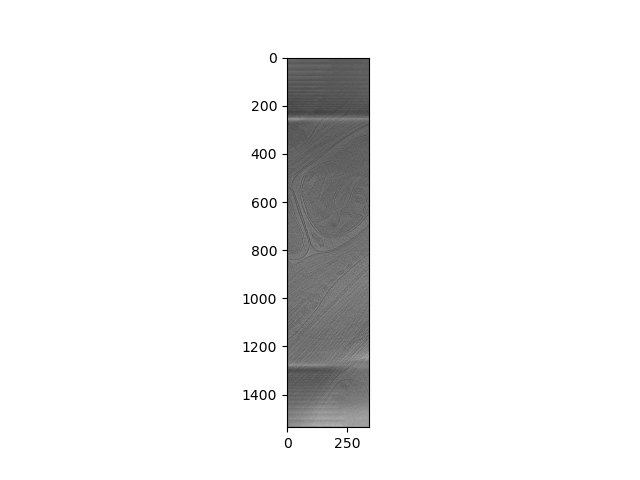

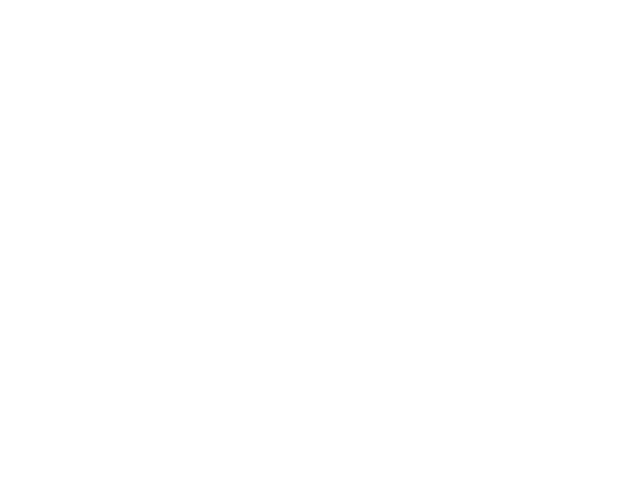

In [177]:
plt.clf()
plt.figure()
plt.imshow(rec_[100])
plt.show()

In [178]:
maxiter = 100
rec_ = torch.tensor(rec_).to(device).float().reshape(1,1,rec_.shape[0],rec_.shape[1],rec_.shape[2])
pred = rec_.clone()
lambda_ = 0.1
sigma = torch.tensor(10).repeat(1,1,1,1,1).to(device)
res = 1
with torch.no_grad():
    while res > 1e-4:
        new_pred = pred - (pred - rec_ + lambda_*model.grad(pred, sigma=sigma))/(1 + lambda_*L_R)
        res = torch.norm(new_pred - pred)/torch.norm(pred)
        print(res)
        pred = new_pred

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.23 GiB. GPU 0 has a total capacty of 31.75 GiB of which 337.19 MiB is free. Including non-PyTorch memory, this process has 31.41 GiB memory in use. Of the allocated memory 19.85 GiB is allocated by PyTorch, and 5.06 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

pred min max :  0.00019092564 0.0010542494
Hty min max :  -0.001062257 0.0030152714



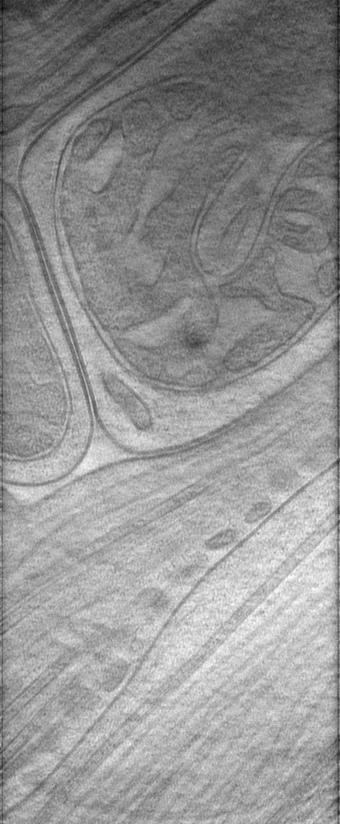
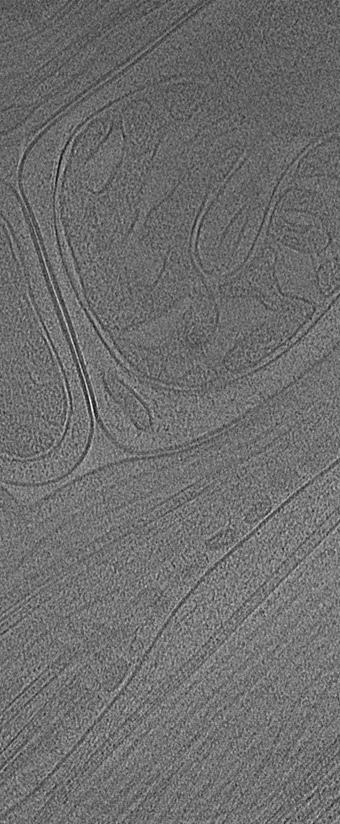

In [22]:
pred_im = pred[0,0,100].cpu().numpy()[v_shape[1]//2-412:v_shape[1]//2+412,:]
Hty_im = rec_[0,0,100].cpu().numpy()[v_shape[1]//2-412:v_shape[1]//2+412,:]
print('pred min max : ', np.min(pred_im), np.max(pred_im))
print('Hty min max : ', np.min(Hty_im), np.max(Hty_im))
compare(pred_im, Hty_im, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=500)



## Plotting all results (Bern, Adjoint, CGD, PGD TV, PnP)

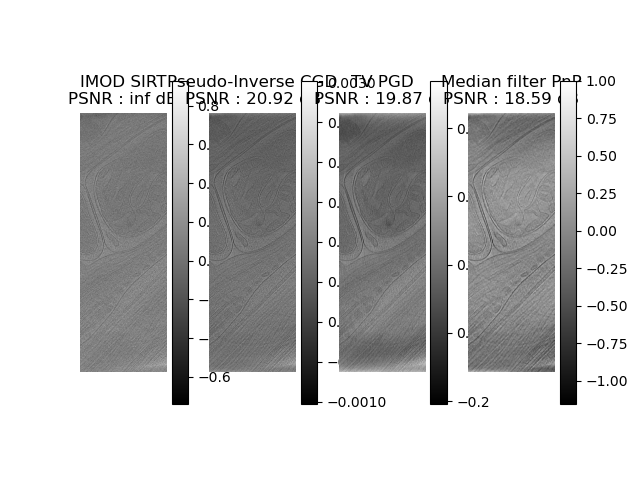

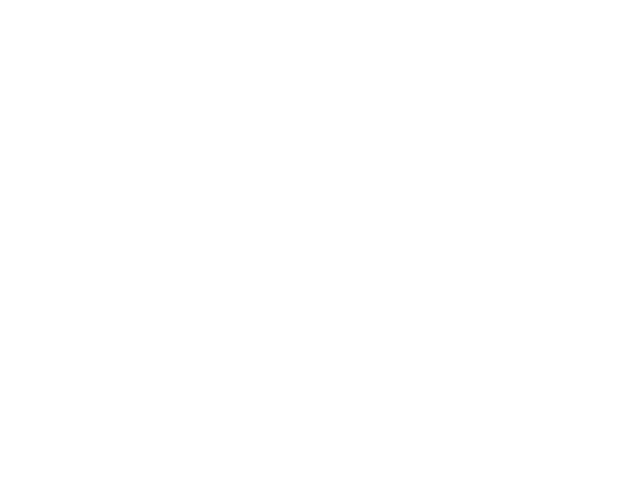

In [27]:
from skimage.metrics import peak_signal_noise_ratio as psnr
recBern = rec_bern_downsampled[:, rec_bern_downsampled.shape[1]//2 - roi:rec_bern_downsampled.shape[1]//2 + roi][::2,::2]
plt.clf()
plt.figure('results')
plt.subplot(1,4,1)
plt.imshow(recBern)
pnsr = psnr(recBern, recBern)
plt.title("IMOD SIRT"+'\n'+"PSNR : "+str(round(pnsr, 2))+" dB")
plt.colorbar()
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
pnsr = psnr(recBern, recon_pinv_cpu[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
plt.title("Pseudo-Inverse CGD"+'\n'+"PSNR : "+str(round(pnsr, 2))+" dB")
plt.colorbar()
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(recon_pd[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
pnsr = psnr(recBern, recon_pd[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
plt.title("TV PGD"+'\n'+"PSNR : "+str(round(pnsr, 2))+" dB")
plt.colorbar()
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(rec_pnp)
pnsr = psnr(recBern, rec_pnp)
plt.title("Median filter PnP"+'\n'+"PSNR : "+str(round(pnsr, 2))+" dB")
plt.axis('off')
plt.colorbar()
plt.show()
